# Pancreatic Cancer Classification from Liquid Biopsy RNA-seq Data

This notebook presents the step-by-step solution for classifying pancreatic cancer based on gene expression data obtained from platelet RNA-seq.

Goal: Build a binary classifier distinguishing pancreatic cancer samples from controls (healthy + pancreatic diseases).

---

## 1. Loading the dataset

The data consists of two files:
- counts_pancreatic.csv - gene expression matrix (genes x samples), transposed so that rows correspond to samples and columns to genes.
- samples_pancreatic.xlsx - sample metadata (Group, Sex, Age, Stage, etc.).

Both files are joined on shared sample indices. The resulting Dataset object contains:
- X - DataFrame with gene expression values
- y - class label (Group)
- meta - full metadata
- age, sex - helper columns

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder

from utilz.Dataset import load_dataset
from utilz.constans import HEALTHY, DISEASE, CANCER

meta_path = r"../data/samples_pancreatic.xlsx"
data_path = r"../data/counts_pancreatic.csv"

ds = load_dataset(data_path, meta_path, label_col="Group")

# Constants
TEST_SIZE = 0.2
VALID_SIZE = 0.2
# Preprocessing hyperparameters
ANOVA_PERCENTILE = 60
MEAN_PERCENTILE = 20

print(f"Number of samples: {ds.X.shape[0]}")
print(f"Number of genes:   {ds.X.shape[1]}")
print(f"\nOriginal class distribution:")
print(ds.y.value_counts())

[INFO] skipped 1973 probs due to missing metadata
Number of samples: 584
Number of genes:   42630

Original class distribution:
Group
Asymptomatic controls    410
Pancreatic cancer        124
Pancreatic diseases       50
Name: count, dtype: int64


### 1.1. Metadata overview

Overview of sample metadata - demographic and clinical variables that may be potential sources of bias.

In [2]:
ds.meta.head()

,Sex,Age,Group,Institution,Lib.size,Stage,RealLocation,Mode,CA125,Platelets,Histology,Datasplit,Gdansk_sample_name,StageFull,LeukoMichal,PTPRC
AMC-HD-001-TR1139,M,23.0,Asymptomatic controls,Institute 1,1065633,NaN,AMC,Single,NaN,NaN,NaN,Train,NaN,n.a.,9257.408507,167.036869
AMC-HD-002-TR1140,F,20.0,Asymptomatic controls,Institute 1,1126605,NaN,AMC,Single,NaN,NaN,NaN,Test,NaN,n.a.,7145.361506,47.043995
AMC-HD-003-TR1141,F,21.0,Asymptomatic controls,Institute 1,698667,NaN,AMC,Single,NaN,NaN,NaN,Validation,NaN,n.a.,10362.590476,88.740416
AMC-HD-004-TR1142,F,21.0,Asymptomatic controls,Institute 1,850492,NaN,AMC,Single,NaN,NaN,NaN,Train,NaN,n.a.,5721.394205,23.515800
AMC-HD-005-TR1143,F,21.0,Asymptomatic controls,Institute 1,824835,NaN,AMC,Single,NaN,NaN,NaN,Test,NaN,n.a.,14561.700219,58.193457


In [3]:
print(f"Columns: {list(ds.meta.columns)}")
print(f"Sex:     {ds.sex.value_counts().to_dict()}")
print(f"Age:     min={ds.age.min():.0f}, max={ds.age.max():.0f}, "
      f"median={ds.age.median():.0f}, mean={ds.age.mean():.1f}")
print(f"Stage:   {ds.meta['Stage'].value_counts().to_dict()}")

Columns: ['Sex', 'Age', 'Group', 'Institution', 'Lib.size', 'Stage', 'RealLocation', 'Mode', 'CA125', 'Platelets', 'Histology', 'Datasplit', 'Gdansk_sample_name', 'StageFull', 'LeukoMichal', 'PTPRC']
Sex:     {'F': 316, 'M': 253, 'n.a.': 15}
Age:     min=18, max=87, median=56, mean=54.1
Stage:   {'II': 64, 'III': 31, 'IV': 26, 'I': 3}


### 1.2. Expression matrix - basic statistics

In [4]:

print(f"Shape (samples x genes): {ds.X.shape[0]} x {ds.X.shape[1]}")
print(f"Value range: [{ds.X.min().min():.2f}, {ds.X.max().max():.2f}]")
print(f"Missing values: {ds.X.isna().sum().sum()}")

ds.X.head(10).describe()

Shape (samples x genes): 584 x 42630
Value range: [2.28, 17.51]
Missing values: 0


,ENSG00000000003,ENSG00000000005,ENSG00000000419,ENSG00000000457,ENSG00000000460,ENSG00000000938,ENSG00000000971,ENSG00000001036,ENSG00000001084,ENSG00000001167,...,ENSG00000288709,ENSG00000288710,ENSG00000288714,ENSG00000288717,ENSG00000288718,ENSG00000288719,ENSG00000288720,ENSG00000288721,ENSG00000288722,ENSG00000288723
count,10.000000,1.000000e+01,10.000000,10.000000,10.000000,10.00000,10.000000,10.000000,10.000000,10.000000,...,1.000000e+01,1.000000e+01,10.000000,10.00000,1.000000e+01,1.000000e+01,1.000000e+01,1.000000e+01,1.000000e+01,1.000000e+01
mean,2.452700,2.278000e+00,3.881200,2.668800,3.731600,4.74670,2.327100,4.326000,2.581600,2.449700,...,2.278000e+00,2.278000e+00,2.407900,2.42950,2.278000e+00,2.278000e+00,2.278000e+00,2.278000e+00,2.278000e+00,2.278000e+00
std,0.369592,4.681111e-16,0.947267,0.519309,0.526035,1.29198,0.155268,0.453664,0.494315,0.362757,...,4.681111e-16,4.681111e-16,0.283863,0.25239,4.681111e-16,4.681111e-16,4.681111e-16,4.681111e-16,4.681111e-16,4.681111e-16
min,2.278000,2.278000e+00,2.278000,2.278000,3.062000,2.27800,2.278000,3.726000,2.278000,2.278000,...,2.278000e+00,2.278000e+00,2.278000,2.27800,2.278000e+00,2.278000e+00,2.278000e+00,2.278000e+00,2.278000e+00,2.278000e+00
25%,2.278000,2.278000e+00,3.661250,2.278000,3.310000,4.25550,2.278000,3.979500,2.278000,2.278000,...,2.278000e+00,2.278000e+00,2.278000,2.27800,2.278000e+00,2.278000e+00,2.278000e+00,2.278000e+00,2.278000e+00,2.278000e+00
50%,2.278000,2.278000e+00,3.838000,2.278000,3.769500,4.62500,2.278000,4.234500,2.278000,2.278000,...,2.278000e+00,2.278000e+00,2.278000,2.27800,2.278000e+00,2.278000e+00,2.278000e+00,2.278000e+00,2.278000e+00,2.278000e+00
75%,2.278000,2.278000e+00,4.300250,3.079000,3.972750,5.11250,2.278000,4.532000,2.959750,2.278000,...,2.278000e+00,2.278000e+00,2.278000,2.53975,2.278000e+00,2.278000e+00,2.278000e+00,2.278000e+00,2.278000e+00,2.278000e+00
max,3.217000,2.278000e+00,5.789000,3.469000,4.816000,7.29100,2.769000,5.120000,3.469000,3.187000,...,2.278000e+00,2.278000e+00,3.086000,2.88600,2.278000e+00,2.278000e+00,2.278000e+00,2.278000e+00,2.278000e+00,2.278000e+00


---

## 2. Label preparation - binary classification

The dataset contains three original classes:
- Asymptomatic control - healthy individuals
- Pancreatic diseases - other pancreatic conditions
- Pancreatic cancer - pancreatic cancer

The goal is to detect pancreatic cancer, so we merge Asymptomatic controls and Pancreatic diseases into a single control class. The problem becomes binary classification:

| New label | Original classes |
|---|---|
| 0 - Control | Asymptomatic controls + Pancreatic diseases |
| 1 - Cancer | Pancreatic cancer |

In [5]:
ds.y = ds.y.replace({DISEASE: HEALTHY})

print("Class distribution after merging:")
print(ds.y.value_counts())
print(f"\nClass ratio (control/cancer): {(ds.y == HEALTHY).sum() / (ds.y == CANCER).sum():.2f}")

Class distribution after merging:
Group
Asymptomatic controls    460
Pancreatic cancer        124
Name: count, dtype: int64

Class ratio (control/cancer): 3.71


In [6]:
# Encode labels numerically
le = LabelEncoder()
y_encoded = pd.Series(le.fit_transform(ds.y), index=ds.y.index)

print("Class mapping:")
print(f"{le.classes_[0]} -> {le.transform(le.classes_)[0]}")
print(f"{le.classes_[1]} -> {le.transform(le.classes_)[1]}")

print("Encoded label distribution:")
print(y_encoded.value_counts().sort_index())

Class mapping:
Asymptomatic controls -> 0
Pancreatic cancer -> 1
Encoded label distribution:
0    460
1    124
Name: count, dtype: int64


---

## 3. Train / Test / Validation split

The data is split as follows:
- 60% - training set
- 20% - validation set (used for decision threshold tuning)
- 20% - test set (used for final model evaluation)

### Stratification

To avoid bias in the split, we apply combined stratification across four variables:
1. Class (y) - cancer vs. control
2. Sex
3. Age group (Age quantiled into 3 bins: young/mid/old)
4. Stage (grouped as I_II / III / IV)

This ensures that each subset maintains similar proportions of these variables, minimizing the risk of confounding.

In [7]:
X_train, X_test, X_valid, y_train, y_test, y_valid = (
    ds.get_train_test_valid_split(ds.X, y_encoded, test_size=TEST_SIZE, valid_size=VALID_SIZE)
)

print(f"Split sizes:")
print(f"  Train:      {X_train.shape[0]} samples ({X_train.shape[0]/ds.X.shape[0]*100:.1f}%)")
print(f"  Validation: {X_valid.shape[0]} samples ({X_valid.shape[0]/ds.X.shape[0]*100:.1f}%)")
print(f"  Test:       {X_test.shape[0]} samples ({X_test.shape[0]/ds.X.shape[0]*100:.1f}%)")
print(f"  Total:      {X_train.shape[0] + X_valid.shape[0] + X_test.shape[0]} samples")
print(f"\nNumber of features: {X_train.shape[1]}")

[INFO] 8 samples with unique strata added to train set
[INFO] 4 samples with unique strata (2nd split) added to train set

[ASSERTION PASSED] No leakage detected between splits.
Split sizes:
  Train:      357 samples (61.1%)
  Validation: 114 samples (19.5%)
  Test:       113 samples (19.3%)
  Total:      584 samples

Number of features: 42630


### 3.1. Split balance overview

Class counts, proportions, and demographic distributions across train/test/validation splits.

In [8]:
split_summary = pd.DataFrame({
    'Train': y_train.value_counts().sort_index(),
    'Validation': y_valid.value_counts().sort_index(),
    'Test': y_test.value_counts().sort_index(),
})
split_summary.index = [le.inverse_transform([i])[0] for i in split_summary.index]
split_summary.loc['Total'] = split_summary.sum()
display(split_summary)

# Class proportions per split
split_pct = pd.DataFrame({
    'Train (%)': y_train.value_counts(normalize=True).sort_index() * 100,
    'Validation (%)': y_valid.value_counts(normalize=True).sort_index() * 100,
    'Test (%)': y_test.value_counts(normalize=True).sort_index() * 100,
})
split_pct.index = [le.inverse_transform([i])[0] for i in split_pct.index]
display(split_pct.round(1))

from utilz.helpers import plot_split_balance
stage_col = ds.meta['Stage'].copy()
stage_col = stage_col.replace({'I': 'I-II', 'II': 'I-II'})

plot_split_balance({
    'Train': (y_train, ds.sex.loc[X_train.index], ds.age.loc[X_train.index], ds.meta["Stage"].loc[X_train.index].replace({'I': 'I-II', 'II': 'I-II'})),
    'Test':  (y_test,  ds.sex.loc[X_test.index],  ds.age.loc[X_test.index],  ds.meta["Stage"].loc[X_test.index].replace({'I': 'I-II', 'II': 'I-II'})),
    'Valid': (y_valid, ds.sex.loc[X_valid.index], ds.age.loc[X_valid.index], ds.meta["Stage"].loc[X_valid.index].replace({'I': 'I-II', 'II': 'I-II'})),
})

,Train,Validation,Test
Asymptomatic controls,276,92,92
Pancreatic cancer,81,22,21
Total,357,114,113


,Train (%),Validation (%),Test (%)
Asymptomatic controls,77.3,80.7,81.4
Pancreatic cancer,22.7,19.3,18.6


### 3.2. Data leakage check

Verify that no sample appears in more than one split.

In [9]:
train_test_overlap = X_train.index.intersection(X_test.index)
train_valid_overlap = X_train.index.intersection(X_valid.index)
test_valid_overlap = X_test.index.intersection(X_valid.index)

print(f"Overlap Train - Test:       {len(train_test_overlap)}")
print(f"Overlap Train - Validation: {len(train_valid_overlap)}")
print(f"Overlap Test  - Validation: {len(test_valid_overlap)}")

assert len(train_test_overlap) + len(train_valid_overlap) + len(test_valid_overlap) == 0, \
    "Data leakage detected!"
print("\nNo data leakage - all splits are disjoint.")

Overlap Train - Test:       0
Overlap Train - Validation: 0
Overlap Test  - Validation: 0

No data leakage - all splits are disjoint.


---

## 4. Preprocessing - feature reduction pipeline

The preprocessing pipeline reduces 42,630 genes to a manageable set by sequentially applying:

| Step | Reducer                                    | Purpose |
|---|--------------------------------------------|---|
| 1 | **ConstantExpressionReductor**             | Remove genes with zero variance (single unique value) |
| 2 | **AnovaReductor** (percentile=60)          | Keep top 30% genes by ANOVA F-score vs. class label |
| 3 | **MeanExpressionReductor** (percentile=20) | Remove bottom 10% by mean expression level |
| 4 | **AgeBiasReductor**                        | Remove genes significantly correlated with age (OLS + FDR-BH) |
| 5 | **SexBiasReductor**                        | Remove genes significantly correlated with sex (OLS + FDR-BH) |
| 6 | **StandardScaler**                         | Zero-mean, unit-variance normalization |

All reductors are **fit on the training set only** and applied to validation/test sets to prevent data leakage.

### 4.1. Pipeline definition and gene reduction summary

In [10]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from utilz.preprocessing_utilz import (
    ConstantExpressionReductor, AnovaReductor,
    MeanExpressionReductor, CovariatesBiasReductor,
)

sex_numeric = ds.sex.map({"F": 0, "M": 1})

pipeline = Pipeline([
    ('ConstantExpressionReductor', ConstantExpressionReductor()),
    ('AnovaReductor', AnovaReductor(percentile=ANOVA_PERCENTILE)),
    ('MeanExpressionReductor', MeanExpressionReductor(percentile=MEAN_PERCENTILE)),
    ('AgeBiasReductor',  CovariatesBiasReductor(covariate=ds.age)),
    ('SexBiasReductor',  CovariatesBiasReductor(covariate=sex_numeric)),
    ('scaler', StandardScaler()),
])

# Fit & transform step by step to track gene counts
step_names = []
step_counts = []
step_genes = {}

X_current = X_train.copy()
step_names.append("Raw input")
step_counts.append(X_current.shape[1])
step_genes["Raw input"] = list(X_current.columns)

for name, transformer in pipeline.steps:
    if name == 'scaler':
        transformer.fit(X_current)
        X_current = pd.DataFrame(
            transformer.transform(X_current),
            columns=X_current.columns, index=X_current.index
        )
    else:
        transformer.fit(X_current, y_train)
        X_current = transformer.transform(X_current)
    step_names.append(name)
    step_counts.append(X_current.shape[1])
    if name != 'scaler':
        step_genes[name] = list(transformer.selected_genes_)

# Summary table
reduction_df = pd.DataFrame({
    'Step': step_names,
    'Genes remaining': step_counts,
    'Genes removed': [0] + [step_counts[i] - step_counts[i+1] for i in range(len(step_counts)-1)],
})
reduction_df['% of original'] = (reduction_df['Genes remaining'] / step_counts[0] * 100).round(1)

print(f"Preprocessing pipeline: {step_counts[0]} → {step_counts[-1]} genes\n")
reduction_df

data shape after ConstantExpressionReductor:  (357, 30733)
data shape after AnovaReductor:  (357, 12293)
data shape after MeanExpressionReductor:  (357, 9834)
data shape after CovariatesBiasReductor:  (357, 7491)
data shape after CovariatesBiasReductor:  (357, 7477)
Preprocessing pipeline: 42630 → 7477 genes



,Step,Genes remaining,Genes removed,% of original
0,Raw input,42630,0,100.0
1,ConstantExpressionReductor,30733,11897,72.1
2,AnovaReductor,12293,18440,28.8
3,MeanExpressionReductor,9834,2459,23.1
4,AgeBiasReductor,7491,2343,17.6
5,SexBiasReductor,7477,14,17.5
6,scaler,7477,0,17.5


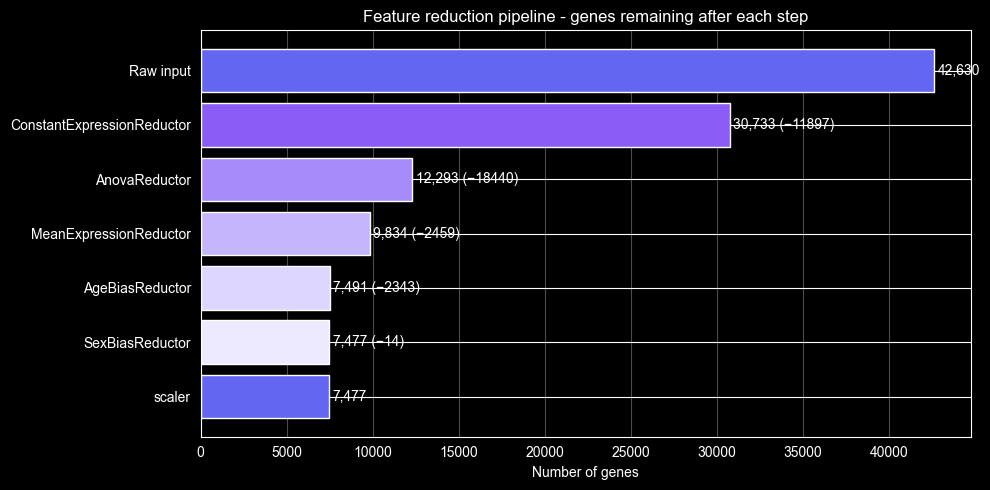

In [11]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#6366f1', '#8b5cf6', '#a78bfa', '#c4b5fd', '#ddd6fe', '#ede9fe']
bars = ax.barh(range(len(step_names)), step_counts, color=colors[:len(step_names)])

for i, (count, name) in enumerate(zip(step_counts, step_names)):
    removed = f" (−{step_counts[i-1] - count})" if i > 0 and step_counts[i-1] != count else ""
    ax.text(count + 200, i, f"{count:,}{removed}", va='center', fontsize=10)

ax.set_yticks(range(len(step_names)))
ax.set_yticklabels(step_names)
ax.invert_yaxis()
ax.set_xlabel("Number of genes")
ax.set_title("Feature reduction pipeline - genes remaining after each step")
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

### 4.2. PCA before and after preprocessing

PCA visualization on the **test set** shows how the preprocessing pipeline improves class separability. Before preprocessing, the 42k-dimensional space contains noise from constant, low-variance, and confounded genes. After filtering, the principal components capture more disease-relevant variation.

=== PCA BEFORE preprocessing ===


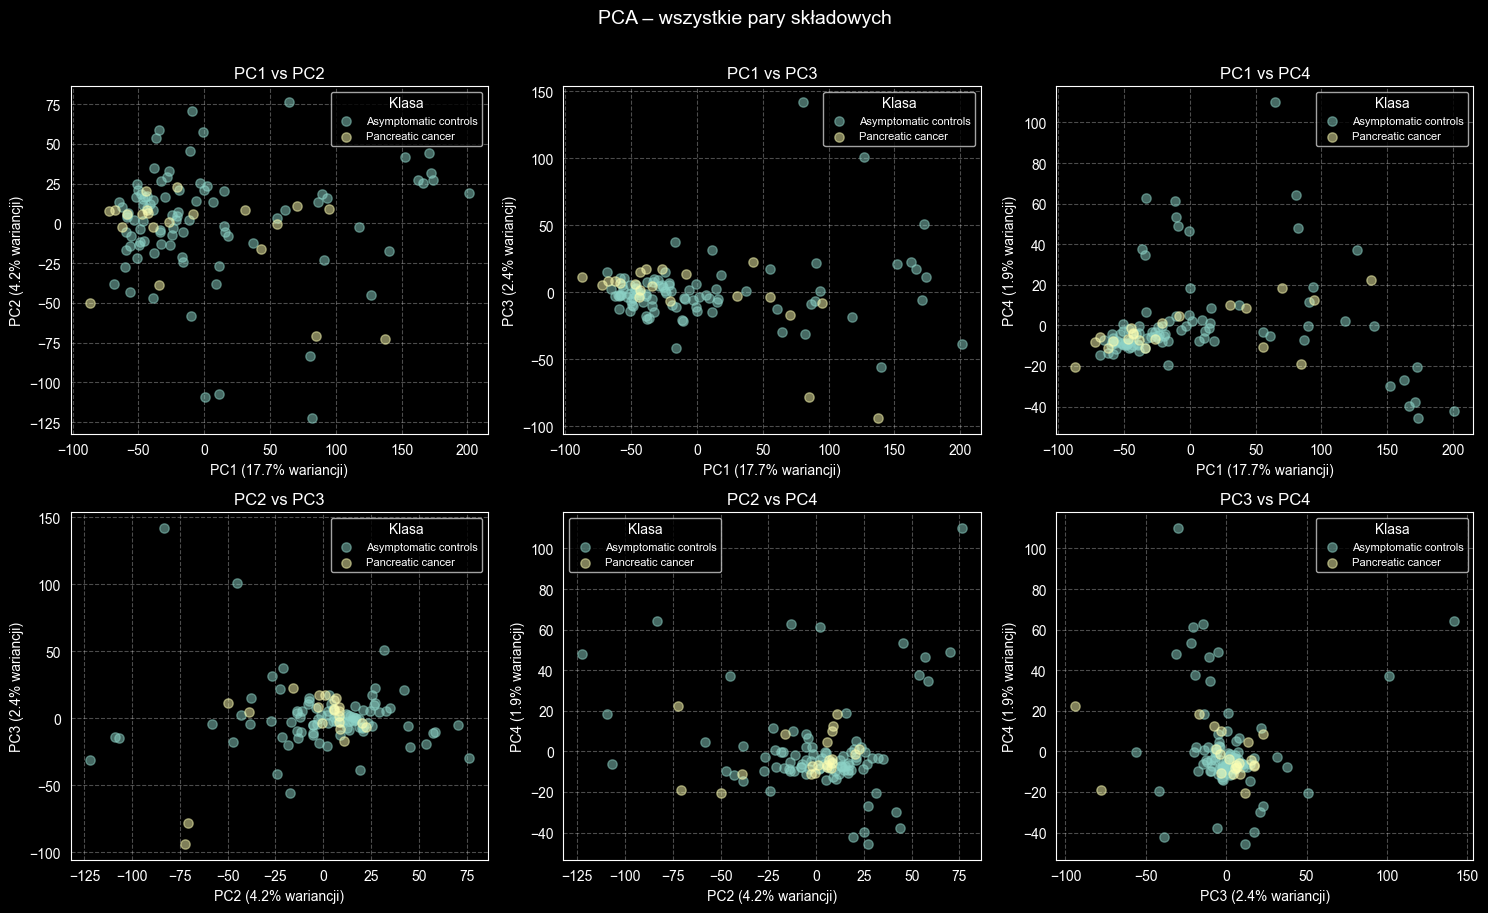

data shape after ConstantExpressionReductor:  (113, 30733)
data shape after AnovaReductor:  (113, 12293)
data shape after MeanExpressionReductor:  (113, 9834)
data shape after CovariatesBiasReductor:  (113, 7491)
data shape after CovariatesBiasReductor:  (113, 7477)

=== PCA AFTER preprocessing (7477 genes) ===


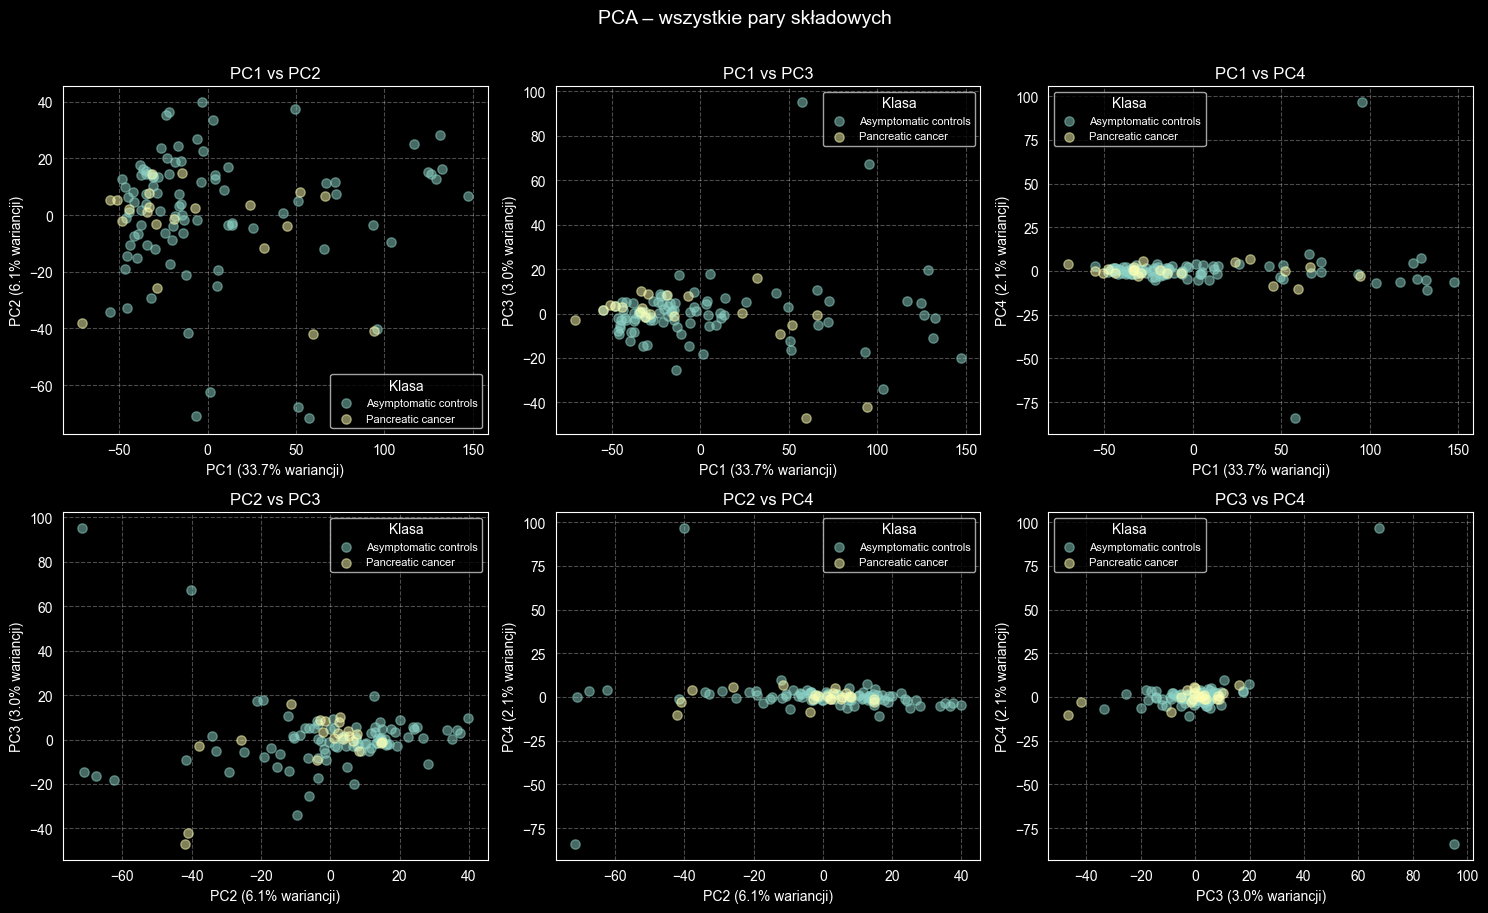

In [12]:
from utilz.helpers import plot_pca

num_pca_components = 4

print("=== PCA BEFORE preprocessing ===")
plot_pca(X_test, y_test, num_pca_components, le)

X_test_filtered = X_test.copy()
for name, transformer in pipeline.steps:
    if name == 'scaler':
        break
    X_test_filtered = transformer.transform(X_test_filtered)

print(f"\n=== PCA AFTER preprocessing ({X_test_filtered.shape[1]} genes) ===")
plot_pca(X_test_filtered, y_test, num_pca_components, le)

### 4.3. ANOVA filtering effect

The AnovaReductor keeps the top genes by ANOVA F-score (between-class variance). Below we compare this with overall gene variance to show which genes are retained.

data shape after ConstantExpressionReductor:  (357, 30733)


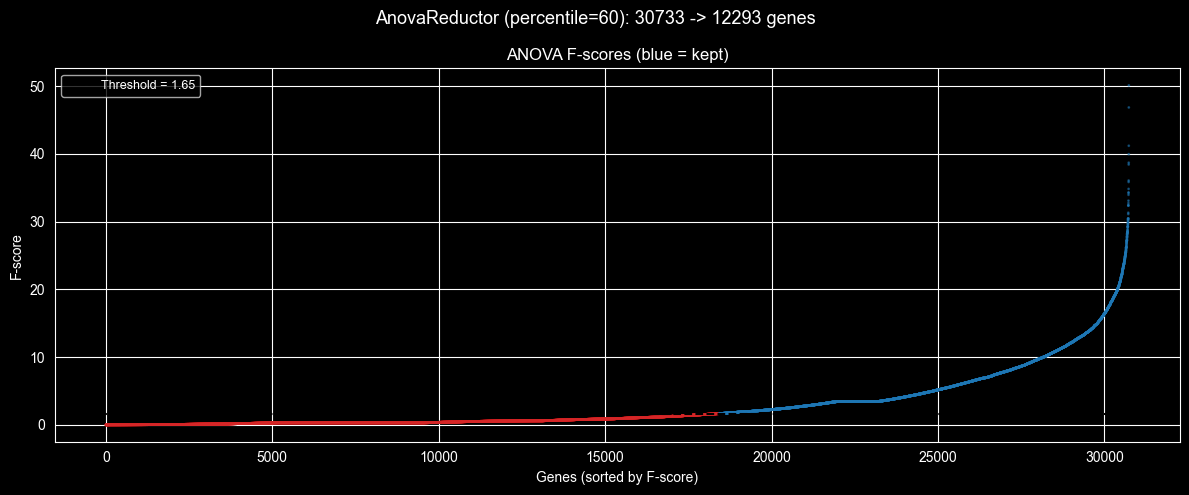

In [13]:
from sklearn.feature_selection import f_classif

const_reductor = pipeline.named_steps['ConstantExpressionReductor']
X_after_const = const_reductor.transform(X_train)
f_scores, p_values = f_classif(X_after_const, y_train)
threshold = np.percentile(f_scores, ANOVA_PERCENTILE)
kept_mask = f_scores > threshold

fig, ax = plt.subplots(figsize=(12, 5))
sorted_f_idx = np.argsort(f_scores)
sorted_f = f_scores[sorted_f_idx]
colors_f = ['tab:blue' if f > threshold else 'tab:red' for f in sorted_f]
ax.scatter(range(len(sorted_f)), sorted_f, c=colors_f, s=1, alpha=0.5)  # ← ax.scatter
ax.axhline(threshold, color='black', ls='--', lw=1.5, label=f'Threshold = {threshold:.2f}')
ax.set(xlabel='Genes (sorted by F-score)', ylabel='F-score',
       title='ANOVA F-scores (blue = kept)')
ax.legend(fontsize=9)

plt.suptitle(f'AnovaReductor (percentile={ANOVA_PERCENTILE}): {len(f_scores)} -> {kept_mask.sum()} genes', fontsize=13)
plt.tight_layout()
plt.show()

### 4.4. Age bias removal - validation

To verify that the AgeBiasReductor effectively removes age-correlated signal, we train a simple age prediction model (Lasso regression) on healthy controls before and after debiasing. A successful reductor should **decrease** the model's ability to predict age from gene expression, confirming that confounding age signal has been removed.

data shape after ConstantExpressionReductor:  (344, 30422)
data shape after MeanExpressionReductor:  (344, 24337)
data shape after ConstantExpressionReductor:  (108, 30422)
data shape after MeanExpressionReductor:  (108, 24337)
data shape after ConstantExpressionReductor:  (108, 30422)
data shape after MeanExpressionReductor:  (108, 24337)
data shape after ConstantExpressionReductor:  (108, 30422)
data shape after MeanExpressionReductor:  (108, 24337)
data shape after ConstantExpressionReductor:  (344, 30422)
data shape after MeanExpressionReductor:  (344, 24337)
data shape after CovariatesBiasReductor:  (344, 18598)
data shape after ConstantExpressionReductor:  (108, 30422)
data shape after MeanExpressionReductor:  (108, 24337)
data shape after CovariatesBiasReductor:  (108, 18598)
data shape after ConstantExpressionReductor:  (108, 30422)
data shape after MeanExpressionReductor:  (108, 24337)
data shape after CovariatesBiasReductor:  (108, 18598)
data shape after ConstantExpressionRe

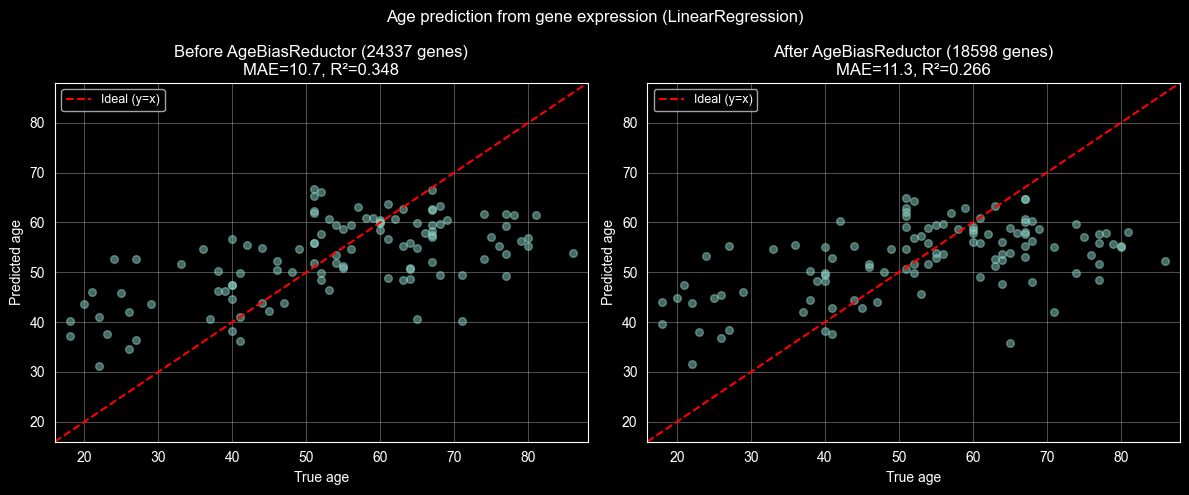

In [14]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error

# Two pipelines: with and without AgeBiasReductor
pipe_without_age = Pipeline([
    ('ConstantExpressionReductor', ConstantExpressionReductor()),
    ('MeanExpressionReductor', MeanExpressionReductor(percentile=MEAN_PERCENTILE)),
    ('scaler', StandardScaler()),
    ('model', LinearRegression()),
])

pipe_with_age = Pipeline([
    ('ConstantExpressionReductor', ConstantExpressionReductor()),
    ('MeanExpressionReductor', MeanExpressionReductor(percentile=MEAN_PERCENTILE)),
    ('AgeBiasReductor', CovariatesBiasReductor(covariate=ds.age)),
    ('scaler', StandardScaler()),
    ('model', LinearRegression()),
])

age = ds.age.dropna().astype(int)
tr_idx = X_train.index.intersection(age.index)
te_idx = X_test.index.intersection(age.index)

# --- Before AgeBiasReductor ---
pipe_without_age.fit(X_train.loc[tr_idx], age.loc[tr_idx])
pred_before = pipe_without_age.predict(X_test.loc[te_idx])
n_before = pipe_without_age[:-1].transform(X_test.loc[te_idx]).shape[1]
mae_before = mean_absolute_error(age.loc[te_idx], pred_before)
r2_before = pipe_without_age.score(X_test.loc[te_idx], age.loc[te_idx])

# --- After AgeBiasReductor ---
pipe_with_age.fit(X_train.loc[tr_idx], age.loc[tr_idx])
pred_after = pipe_with_age.predict(X_test.loc[te_idx])
n_after = pipe_with_age[:-1].transform(X_test.loc[te_idx]).shape[1]
mae_after = mean_absolute_error(age.loc[te_idx], pred_after)
r2_after = pipe_with_age.score(X_test.loc[te_idx], age.loc[te_idx])

print(f"Before AgeBiasReductor ({n_before} genes): MAE={mae_before:.2f} years, R²={r2_before:.4f}")
print(f"After AgeBiasReductor  ({n_after} genes):  MAE={mae_after:.2f} years, R²={r2_after:.4f}")

# Plot
y_true = age.loc[te_idx]
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

for ax, pred, n, mae, r2, title in [
    (ax1, pred_before, n_before, mae_before, r2_before, "Before AgeBiasReductor"),
    (ax2, pred_after, n_after, mae_after, r2_after, "After AgeBiasReductor"),
]:
    lim = [min(y_true.min(), pred.min()) - 2, max(y_true.max(), pred.max()) + 2]
    ax.scatter(y_true, pred, alpha=0.5, s=30)
    ax.plot(lim, lim, 'r--', label='Ideal (y=x)')
    ax.set(xlim=lim, ylim=lim, xlabel="True age", ylabel="Predicted age",
           title=f"{title} ({n} genes)\nMAE={mae:.1f}, R²={r2:.3f}")
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

plt.suptitle("Age prediction from gene expression (LinearRegression)", fontsize=12)
plt.tight_layout()
plt.show()

### 4.5. Sex bias removal - validation

Analogous test for SexBiasReductor: we train a sex classifier (Logistic Regression) on healthy controls before and after removing sex-correlated genes. A successful reductor should decrease sex classification accuracy.

In [15]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import balanced_accuracy_score, f1_score

# Two pipelines: with and without SexBiasReductor
pipe_without_sex = Pipeline([
    ('ConstantExpressionReductor', ConstantExpressionReductor()),
    ('MeanExpressionReductor', MeanExpressionReductor(percentile=MEAN_PERCENTILE)),
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=1500, class_weight='balanced')),
])

pipe_with_sex = Pipeline([
    ('ConstantExpressionReductor', ConstantExpressionReductor()),
    ('MeanExpressionReductor', MeanExpressionReductor(percentile=MEAN_PERCENTILE)),
    ('SexBiasReductor', CovariatesBiasReductor(covariate=sex_numeric)),
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=1500, class_weight='balanced')),
])

sex = sex_numeric.dropna().astype(int)
tr_idx_s = X_train.index.intersection(sex.index)
te_idx_s = X_test.index.intersection(sex.index)

# --- Before SexBiasReductor ---
pipe_without_sex.fit(X_train.loc[tr_idx_s], sex.loc[tr_idx_s])
pred_before_sex = pipe_without_sex.predict(X_test.loc[te_idx_s])
n_before_sex = pipe_without_sex[:-1].transform(X_test.loc[te_idx_s]).shape[1]
ba_before = balanced_accuracy_score(sex.loc[te_idx_s], pred_before_sex)
f1_before = f1_score(sex.loc[te_idx_s], pred_before_sex, average='weighted')

# --- After SexBiasReductor ---
pipe_with_sex.fit(X_train.loc[tr_idx_s], sex.loc[tr_idx_s])
pred_after_sex = pipe_with_sex.predict(X_test.loc[te_idx_s])
n_after_sex = pipe_with_sex[:-1].transform(X_test.loc[te_idx_s]).shape[1]
ba_after = balanced_accuracy_score(sex.loc[te_idx_s], pred_after_sex)
f1_after = f1_score(sex.loc[te_idx_s], pred_after_sex, average='weighted')

print("Sex classification (test set):")
print("-" * 55)
print(f"Before SexBiasReductor ({n_before_sex} genes):")
print(f"  Balanced Accuracy: {ba_before:.3f},  F1: {f1_before:.3f}")
print(f"After SexBiasReductor  ({n_after_sex} genes):")
print(f"  Balanced Accuracy: {ba_after:.3f},  F1: {f1_after:.3f}")

data shape after ConstantExpressionReductor:  (347, 30634)
data shape after MeanExpressionReductor:  (347, 24487)
data shape after ConstantExpressionReductor:  (110, 30634)
data shape after MeanExpressionReductor:  (110, 24487)
data shape after ConstantExpressionReductor:  (110, 30634)
data shape after MeanExpressionReductor:  (110, 24487)
data shape after ConstantExpressionReductor:  (347, 30634)
data shape after MeanExpressionReductor:  (347, 24487)
data shape after CovariatesBiasReductor:  (347, 24446)
data shape after ConstantExpressionReductor:  (110, 30634)
data shape after MeanExpressionReductor:  (110, 24487)
data shape after CovariatesBiasReductor:  (110, 24446)
data shape after ConstantExpressionReductor:  (110, 30634)
data shape after MeanExpressionReductor:  (110, 24487)
data shape after CovariatesBiasReductor:  (110, 24446)
Sex classification (test set):
-------------------------------------------------------
Before SexBiasReductor (24487 genes):
  Balanced Accuracy: 0.836

### 4.6. Final preprocessed sets

Apply the full pipeline to produce train/validation/test sets ready for model training.

In [16]:
X_train = pipeline.fit_transform(X_train, y_train)
X_valid = pipeline.transform(X_valid)
X_test = pipeline.transform(X_test)

data shape after ConstantExpressionReductor:  (357, 30733)
data shape after AnovaReductor:  (357, 12293)
data shape after MeanExpressionReductor:  (357, 9834)
data shape after CovariatesBiasReductor:  (357, 7491)
data shape after CovariatesBiasReductor:  (357, 7477)
data shape after ConstantExpressionReductor:  (114, 30733)
data shape after AnovaReductor:  (114, 12293)
data shape after MeanExpressionReductor:  (114, 9834)
data shape after CovariatesBiasReductor:  (114, 7491)
data shape after CovariatesBiasReductor:  (114, 7477)
data shape after ConstantExpressionReductor:  (113, 30733)
data shape after AnovaReductor:  (113, 12293)
data shape after MeanExpressionReductor:  (113, 9834)
data shape after CovariatesBiasReductor:  (113, 7491)
data shape after CovariatesBiasReductor:  (113, 7477)


---

## 5. Ensemble model with calibration

We combine three classifiers — Logistic Regression, SVM (RBF), and XGBoost — using a StackingClassifier, then apply Beta Calibration to improve probability estimates.

| Component | Method | Description |
|---|---|---|
| **StackingClassifier** | Stacking | Meta-learner (LogReg) trained on base model predictions |
| **Beta Calibration** | Post-hoc calibration | Fits a Beta distribution to align predicted probabilities with true frequencies |

All base models use hyperparameters from grid search. Decision threshold is tuned on the validation set (Youden's J statistic).

### 5.1. Base model definitions

Individual classifiers with tuned hyperparameters from grid search.

In [17]:
from sklearn.svm import SVC
from collections import Counter
from sklearn.ensemble import StackingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.metrics import (roc_auc_score, roc_curve, f1_score,
                             balanced_accuracy_score, classification_report, confusion_matrix)

class_counts = Counter(y_train)
scale_pos_weight = class_counts[0] / class_counts[1]

logreg = LogisticRegression(
    solver='saga', max_iter=15000, class_weight='balanced', fit_intercept=True, l1_ratio=0.2
)

svc = SVC(
    kernel='rbf',
    C=9,
    gamma=0.00015,
    class_weight='balanced',
    probability=True,
    random_state=42
)

xgb = XGBClassifier(
    scale_pos_weight=scale_pos_weight, n_estimators=500, random_state=2137
)

print(f"Class ratio (neg/pos): {scale_pos_weight:.2f}")
print(f"Base models: LogisticRegression, RF, XGBClassifier")

Class ratio (neg/pos): 3.41
Base models: LogisticRegression, RF, XGBClassifier


In [18]:
for name, model in [("LogReg", logreg), ("SVC", svc), ("XGB", xgb)]:
    model.fit(X_train, y_train)
    y_prob = model.predict_proba(X_test)[:, 1]

    y_valid_prob = model.predict_proba(X_valid)[:, 1]
    fpr_v, tpr_v, thr_v = roc_curve(y_valid, y_valid_prob)
    best_thr = thr_v[np.argmax(tpr_v - fpr_v)]
    y_pred = (y_prob >= best_thr).astype(int)

    print(f"{name:6s} | AUC: {roc_auc_score(y_test, y_prob):.4f} "
          f"| F1(w): {f1_score(y_test, y_pred, average='weighted'):.4f} "
          f"| BalAcc: {balanced_accuracy_score(y_test, y_pred):.4f}")

LogReg | AUC: 0.9187 | F1(w): 0.8801 | BalAcc: 0.8320
SVC    | AUC: 0.8856 | F1(w): 0.7480 | BalAcc: 0.7893
XGB    | AUC: 0.8561 | F1(w): 0.8311 | BalAcc: 0.7627




### 5.2. StackingClassifier
Stacking with a LogisticRegression meta-learner trained on base model predictions (predict_proba).

In [19]:
from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import StratifiedKFold

stacking = StackingClassifier(
    estimators=[('logreg', logreg), ('xgb', xgb), ('SVC', svc)],
    final_estimator=LogisticRegression(class_weight='balanced', max_iter=100),
    cv=StratifiedKFold(n_splits=2, shuffle=True, random_state=42),
    stack_method='predict_proba',
    passthrough=False
)

stacking.fit(X_train, y_train)
scores_valid_raw = stacking.predict_proba(X_valid)[:, 1]
scores_test_raw = stacking.predict_proba(X_test)[:, 1]

# Threshold tuning on validation set (Youden's J)
fpr_v, tpr_v, thresholds_v = roc_curve(y_valid, scores_valid_raw)
raw_threshold = thresholds_v[np.argmax(tpr_v - fpr_v)]

y_pred_raw = (scores_test_raw >= raw_threshold).astype(int)

print("=== Before calibration ===")
print(f"Optimal threshold: {raw_threshold:.4f}")
print(f"AUC:               {roc_auc_score(y_test, scores_test_raw):.4f}")
print(f"F1 (weighted):     {f1_score(y_test, y_pred_raw, average='weighted'):.4f}")
print(f"Balanced accuracy: {balanced_accuracy_score(y_test, y_pred_raw):.4f}")
print(f"\n{classification_report(y_test, y_pred_raw, target_names=le.classes_)}")
print(f"Confusion matrix:\n{confusion_matrix(y_test, y_pred_raw)}")


=== Before calibration ===
Optimal threshold: 0.2143
AUC:               0.9234
F1 (weighted):     0.8649
Balanced accuracy: 0.8212

                       precision    recall  f1-score   support

Asymptomatic controls       0.94      0.88      0.91        92
    Pancreatic cancer       0.59      0.76      0.67        21

             accuracy                           0.86       113
            macro avg       0.77      0.82      0.79       113
         weighted avg       0.88      0.86      0.86       113

Confusion matrix:
[[81 11]
 [ 5 16]]


---

## 6. SHAP - Feature importance analysis

SHAP (SHapley Additive exPlanations) values quantify each feature's contribution to individual predictions. We compute SHAP values for each base model (Logistic Regression, SVM, XGBoost) to identify the most important genes driving the cancer vs. healthy classification.

### 6.1. SHAP for Logistic Regression

For linear models, SHAP values can be computed efficiently using the `LinearExplainer`. The coefficients directly map to feature contributions.

Number of features: 7477
First 10 genes: ['ENSG00000000003', 'ENSG00000000460', 'ENSG00000000938', 'ENSG00000000971', 'ENSG00000001036', 'ENSG00000001167', 'ENSG00000001631', 'ENSG00000002016', 'ENSG00000002549', 'ENSG00000002745']
SHAP values shape (LogReg): (113, 7477)


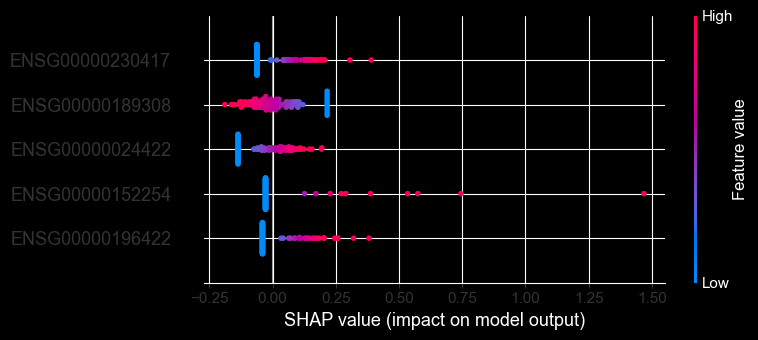

In [20]:
import shap
feature_names = list(pipeline.named_steps['SexBiasReductor'].selected_genes_)
print(f"Number of features: {len(feature_names)}")
print(f"First 10 genes: {feature_names[:10]}")
explainer_lr = shap.LinearExplainer(logreg, X_train)
shap_values_lr = explainer_lr.shap_values(X_test)
print(f"SHAP values shape (LogReg): {shap_values_lr.shape}")
shap.summary_plot(shap_values_lr, X_test, feature_names=feature_names, max_display=5, show=True)

### 6.2. SHAP for SVM (RBF kernel)

For non-linear kernel SVM, we use `KernelExplainer` with a background sample from the training set. This is computationally more expensive but model-agnostic.

100%|██████████| 113/113 [00:28<00:00,  4.03it/s]

SHAP values shape (SVC): (113, 7477)


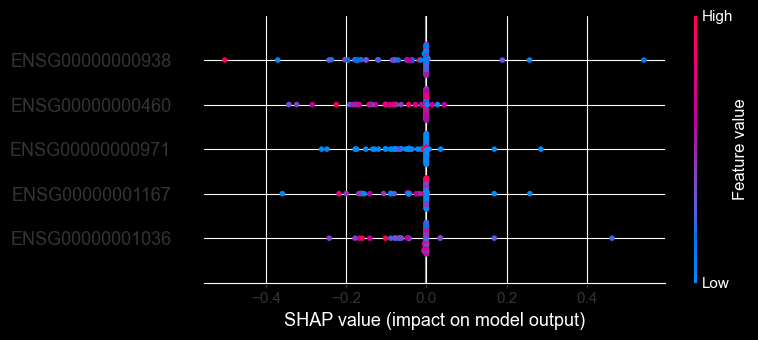

In [21]:
background = shap.kmeans(X_train, 10)
explainer_svc = shap.KernelExplainer(svc.predict_proba, background)
shap_values_svc = explainer_svc.shap_values(X_test, nsamples=10)
shap_values_svc_c1 = shap_values_svc[:, :, 1]
print(f"SHAP values shape (SVC): {shap_values_svc_c1.shape}")
shap.summary_plot(shap_values_svc_c1, X_test, feature_names=feature_names, max_display=5, show=True)

### 6.3. SHAP for XGBoost

XGBoost natively supports `TreeExplainer`, which computes exact SHAP values efficiently using the tree structure.

SHAP values shape (XGB): (113, 7477)


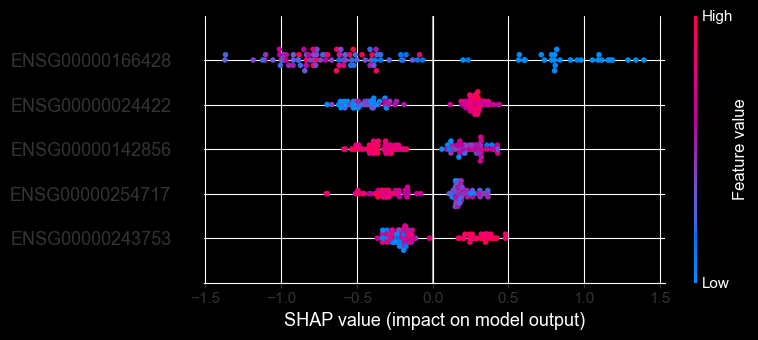

In [22]:
explainer_xgb = shap.TreeExplainer(xgb)
shap_values_xgb = explainer_xgb.shap_values(X_test)
print(f"SHAP values shape (XGB): {shap_values_xgb.shape}")
shap.summary_plot(shap_values_xgb, X_test, feature_names=feature_names, max_display=5, show=True)

### 6.4. Stacking-weighted SHAP gene ranking

Combined gene importance score: for each gene we multiply its mean |SHAP| by the weight that the stacking meta-learner assigns to that base model, then sum across all three models:

$$\text{score}(g) = \sum_{m \in \{\text{LR, SVC, XGB}\}} \overline{|\text{SHAP}_m(g)|} \times w_m$$

where $w_m$ comes from the meta-learner's `coef_` (normalized to sum to 1). This directly reflects how much the final ensemble relies on each base model's predictions.

In [23]:
meta_coef = stacking.final_estimator_.coef_[0]
n_models = len(stacking.estimators_)
if len(meta_coef) == n_models * 2:
    raw_weights = np.array([np.abs(meta_coef[i*2:(i+1)*2]).sum() for i in range(n_models)])
elif len(meta_coef) == n_models:
    raw_weights = np.abs(meta_coef)
else:
    raise ValueError(f"Unexpected coef_ shape: {meta_coef.shape}")

# Normalize to sum to 1
w = raw_weights / raw_weights.sum()
model_names = [name for name, _ in stacking.estimators]

print("Meta-learner weights (normalized):")
for name, wi, ri in zip(model_names, w, raw_weights):
    print(f"  {name:6s}:  w = {wi:.4f}  (raw |coef| = {ri:.4f})")

# --- Mean |SHAP| per gene per model ---
mean_abs_lr  = np.abs(shap_values_lr).mean(axis=0)
mean_abs_svc = np.abs(shap_values_svc_c1).mean(axis=0)
mean_abs_xgb = np.abs(shap_values_xgb).mean(axis=0)

# --- Stacking-weighted combined score ---
shap_map = {'logreg': mean_abs_lr, 'SVC': mean_abs_svc, 'xgb': mean_abs_xgb}
weighted_score = sum(shap_map[name] * wi for (name, _), wi in zip(stacking.estimators, w))

ranking_df = pd.DataFrame({
    'gene': feature_names,
    'SHAP_LR':  mean_abs_lr,
    'SHAP_SVC': mean_abs_svc,
    'SHAP_XGB': mean_abs_xgb,
    'stacking_weighted_score': weighted_score,
}).sort_values('stacking_weighted_score', ascending=False).reset_index(drop=True)

ranking_df.index += 1
ranking_df.index.name = 'rank'

print(f"\nTop 20 genes by stacking-weighted SHAP score:\n")
ranking_df.head(20)

Meta-learner weights (normalized):
  logreg:  w = 0.4525  (raw |coef| = 2.8862)
  xgb   :  w = 0.0277  (raw |coef| = 0.1768)
  SVC   :  w = 0.5197  (raw |coef| = 3.3147)

Top 20 genes by stacking-weighted SHAP score:



,gene,SHAP_LR,SHAP_SVC,SHAP_XGB,stacking_weighted_score
rank,,,,,
1,ENSG00000230417,0.082218,0.000000,0.221162,0.043338
2,ENSG00000024422,0.072713,0.000000,0.364576,0.043012
3,ENSG00000166428,0.050264,0.000000,0.726017,0.042871
4,ENSG00000189308,0.073545,0.000000,0.000000,0.033283
5,ENSG00000142856,0.055058,0.000000,0.297102,0.033152
6,ENSG00000069535,0.058502,0.000000,0.217020,0.032491
7,ENSG00000001036,0.043471,0.020867,0.066581,0.032363
8,ENSG00000274383,0.065523,0.000000,0.095049,0.032287
9,ENSG00000177868,0.061528,0.000000,0.134757,0.031580


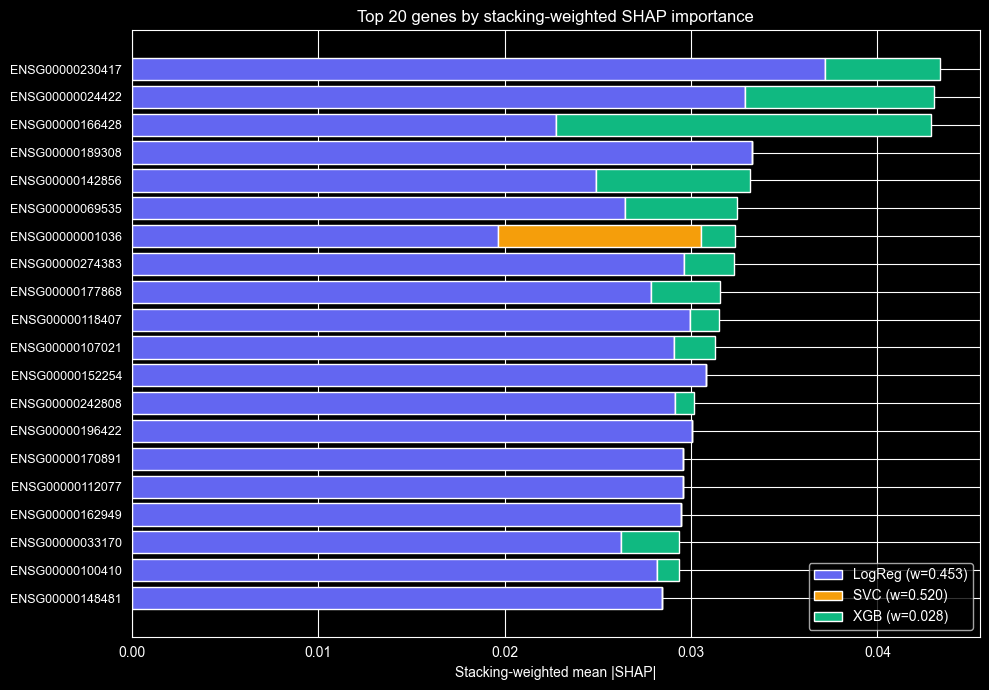

In [24]:
# --- Bar plot: top 20 genes, stacked by model contribution ---
top20 = ranking_df.head(20).copy()

fig, ax = plt.subplots(figsize=(10, 7))

genes = top20['gene'].values
y_pos = np.arange(len(genes))

# Weight names in order of stacking.estimators
w_dict = {name: wi for (name, _), wi in zip(stacking.estimators, w)}

bar_lr  = top20['SHAP_LR'].values  * w_dict['logreg']
bar_svc = top20['SHAP_SVC'].values * w_dict['SVC']
bar_xgb = top20['SHAP_XGB'].values * w_dict['xgb']

ax.barh(y_pos, bar_lr,  label=f'LogReg (w={w_dict["logreg"]:.3f})',  color='#6366f1')
ax.barh(y_pos, bar_svc, left=bar_lr, label=f'SVC (w={w_dict["SVC"]:.3f})', color='#f59e0b')
ax.barh(y_pos, bar_xgb, left=bar_lr + bar_svc, label=f'XGB (w={w_dict["xgb"]:.3f})', color='#10b981')

ax.set_yticks(y_pos)
ax.set_yticklabels(genes, fontsize=9)
ax.invert_yaxis()
ax.set_xlabel('Stacking-weighted mean |SHAP|')
ax.set_title('Top 20 genes by stacking-weighted SHAP importance')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()